# Notebook 01 — Foco Antioquia: Deslizamientos (target binario semanal)

**Objetivo:** Acotar el experimento al departamento de Antioquia, filtrar
exclusivamente eventos de remoción en masa, y construir el **target binario**
a granularidad semanal para responder la pregunta:

> *¿Puede la precipitación acumulada de los últimos 14 días predecir si la semana siguiente habrá deslizamientos en Antioquia?*

**Configuración:** `configs/antioquia_deslizamientos.yaml`
**Continuación de:** `00_experimento_correlacion.ipynb`

**Decisiones de diseño:**

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Granularidad | Semanal | Los deslizamientos ocurren días después de la lluvia, no meses |
| Ventana de precipitación | 14 días anteriores | Captura saturación del suelo previa al evento |
| Horizonte de predicción | 7 días siguientes | Operacionalmente útil para alertas tempranas |
| Target | Binario (0/1) | Sin umbrales arbitrarios — ocurre o no ocurre |
| Desbalance de clases | `class_weight="balanced"` en el modelo | No se manipula el target |

## 0. Entorno y configuración

In [1]:
import sys
from pathlib import Path

_cwd = Path().resolve()
for _p in [_cwd, *_cwd.parents]:
    if (_p / "pyproject.toml").exists():
        _root = _p
        break
else:
    _root = _cwd.parent

sys.path.insert(0, str(_root / "src"))

import warnings
warnings.filterwarnings("ignore")

import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from experiment.config import load_config
from experiment.download import load_ideam, load_ungrd
from experiment.process import clean_ideam, aggregate_weekly_ideam, aggregate_weekly_ungrd

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid")

cfg = load_config(project_root=_root)

print("✓ Configuración cargada")
print(f"  Departamento      : {cfg.geo.departamento}")
print(f"  Período           : {cfg.periodo.anio_inicio} – {cfg.periodo.anio_fin}")
print(f"  Target            : {cfg.target.tipo} — '{cfg.target.nombre}'")
print(f"  Clase positiva    : {cfg.target.clase_positiva} ({cfg.target.clase_positiva_desc})")
print(f"  Clase negativa    : {cfg.target.clase_negativa} ({cfg.target.clase_negativa_desc})")
print(f"  class_weight      : {cfg.target.class_weight}")
print(f"  Ventana precipit. : {cfg.ventanas.precipitacion_dias} días")
print(f"  Horizonte predic. : {cfg.ventanas.prediccion_dias} días")
print(f"  Features          : {len(cfg.all_features)}")

✓ Configuración cargada
  Departamento      : antioquia
  Período           : 2019 – 2022
  Target            : binario — 'deslizamiento'
  Clase positiva    : 1 (Ocurre al menos un deslizamiento en los próximos 7 días)
  Clase negativa    : 0 (No ocurre ningún deslizamiento en los próximos 7 días)
  class_weight      : balanced
  Ventana precipit. : 14 días
  Horizonte predic. : 7 días
  Features          : 10


## 1. Carga de datos crudos

In [2]:
df_ideam_raw = load_ideam(
    anio_inicio=cfg.periodo.anio_inicio,
    anio_fin=cfg.periodo.anio_fin,
)
df_ungrd_raw = load_ungrd()

print(f"IDEAM crudo : {df_ideam_raw.shape}")
print(f"UNGRD crudo : {df_ungrd_raw.shape}")
print(f"\nColumnas UNGRD: {list(df_ungrd_raw.columns)}")

Cargando IDEAM desde cache: C:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops\data\raw\ideam_precipitaciones.csv
Cargando UNGRD desde cache: C:\Users\Mateo Atehortua\Documents\riesgo-deslizamientos-mlops\data\raw\ungrd_emergencias.csv
IDEAM crudo : (240000, 3)
UNGRD crudo : (25857, 71)

Columnas UNGRD: ['fecha', 'departamento', 'municipio', 'evento', 'divipola', 'fallecidos', 'heridos', 'desaparecidos', 'personas', 'familias', 'viviendas_destruidas', 'viviendas_averiadas', 'vias_averiadas', 'puentes_vehiculares', 'puentes_peatonales', 'acueducto', 'alcantarillado', 'centros_de_salud', 'centros_educativos', 'centros_comunitarios', 'hectareas', 'otros_afectacion', 'subsidio_de_arriendo', 'asistencia_no_alimentaria', 'apoyo_alimentario', 'materiales_construccion', 'sacos_bigbag', 'obras_de_emergencia', 'carrotanques_motobombas_planta', 'horas_maquina_retroexcavadora', 'apoyo_aereo_terrestre', 'fic_transferencias_economicas', 'infraesctructura_tecnologica', 'recursos_ejecutado

## 2. Limpieza y filtro geográfico — Antioquia

In [3]:
def _normalize(s: str) -> str:
    """Minúsculas sin tildes — consistente con process.py."""
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFD", s.lower())
    return "".join(c for c in s if unicodedata.category(c) != "Mn")

df_ideam_clean = clean_ideam(df_ideam_raw)

df_ideam = df_ideam_clean[
    df_ideam_clean["departamento"].apply(_normalize) == cfg.geo.departamento
].copy()

print(f"IDEAM Colombia  : {len(df_ideam_clean):,} registros")
print(f"IDEAM Antioquia : {len(df_ideam):,} ({len(df_ideam)/len(df_ideam_clean):.1%})")
print(f"Rango temporal  : {df_ideam['fecha'].min().date()} → {df_ideam['fecha'].max().date()}")

IDEAM limpio: 240,000 registros | 2019-01-01 → 2022-12-01
IDEAM Colombia  : 240,000 registros
IDEAM Antioquia : 17,538 (7.3%)
Rango temporal  : 2019-01-01 → 2022-12-01


## 3. Filtro UNGRD — solo deslizamientos

Se filtran exclusivamente eventos de **remoción en masa** conforme a la
taxonomía de la Ley 1523 de 2012. Las palabras clave se leen del config
(`eventos.landslide_keywords`) — no se hardcodean en el notebook.

In [4]:
evento_col = next(
    (c for c in df_ungrd_raw.columns if any(k in c.lower() for k in ["evento", "tipo"])),
    None,
)
dpto_col = next((c for c in df_ungrd_raw.columns if "depart" in c.lower()), None)
date_col = next((c for c in df_ungrd_raw.columns if "fecha"  in c.lower()), None)

df_ungrd = df_ungrd_raw.copy()

# Filtro 1: tipo de evento
if evento_col:
    mask_evento = df_ungrd[evento_col].apply(
        lambda v: any(k in _normalize(str(v)) for k in cfg.eventos.landslide_keywords)
    )
    df_ungrd = df_ungrd[mask_evento].copy()
    print(f"Después del filtro de evento : {len(df_ungrd):,}")

# Filtro 2: departamento Antioquia
if dpto_col:
    mask_dpto = df_ungrd[dpto_col].apply(lambda v: _normalize(str(v)) == cfg.geo.departamento)
    df_ungrd  = df_ungrd[mask_dpto].copy()
    print(f"Después del filtro geográfico: {len(df_ungrd):,}")

df_ungrd["fecha"]       = pd.to_datetime(df_ungrd[date_col], errors="coerce")
df_ungrd                = df_ungrd.dropna(subset=["fecha"])
df_ungrd["anio"]        = df_ungrd["fecha"].dt.year
df_ungrd["mes"]         = df_ungrd["fecha"].dt.month
df_ungrd["tipo_evento"] = df_ungrd[evento_col] if evento_col else "deslizamiento"

print(f"\n✓ UNGRD Antioquia (deslizamientos): {len(df_ungrd):,} eventos")
print(f"  Período: {df_ungrd['fecha'].min().date()} → {df_ungrd['fecha'].max().date()}")
print(f"\nTipos de evento capturados:")
display(df_ungrd["tipo_evento"].value_counts().to_frame("n"))

Después del filtro de evento : 6,106
Después del filtro geográfico: 945

✓ UNGRD Antioquia (deslizamientos): 945 eventos
  Período: 2019-03-01 → 2022-12-23

Tipos de evento capturados:


,n
tipo_evento,
MOVIMIENTO EN MASA,945


## 4. Agregación semanal y construcción del target binario

### Lógica del join temporal

La clave de este planteamiento es el **shift de una semana en los eventos**:

```
Semana S   → precipitación acumulada 14 días  →  FEATURES del modelo
Semana S+1 → ¿ocurrió al menos un deslizamiento? → TARGET del modelo
```

Esto se implementa desplazando el índice de los eventos una semana hacia atrás
antes del join, de forma que cada fila del dataset quede:
- **Features:** precipitación acumulada en los 14 días que terminan en la semana S
- **Target:** si hubo deslizamiento en la semana S+1

> **¿Por qué binario?**
> El target `deslizamiento = 1` si ocurrió al menos un evento esa semana siguiente,
> `0` si no ocurrió ninguno. No requiere umbrales subjetivos.
> El desbalance de clases se maneja con `class_weight` en el modelo,
> nunca manipulando el target.

In [5]:
# Precipitación semanal con ventanas de 14 días
# (la función aggregate_weekly_ideam construye todas las features en process.py)
precip_semanal = aggregate_weekly_ideam(df_ideam)

# Eventos UNGRD agregados a nivel semanal
desli_semanal  = aggregate_weekly_ungrd(df_ungrd)

print(f"Semanas con datos de precipitación : {len(precip_semanal):,}")
print(f"Semanas con al menos un evento     : {len(desli_semanal):,}")

IDEAM semanal: 205 semanas
Semanas con datos de precipitación : 205
Semanas con al menos un evento     : 133


In [6]:
# Join con shift: precipitación semana S → target semana S+1
# El shift(-1) desplaza los eventos una posición hacia atrás en el índice,
# alineando cada semana de precipitación con los eventos de la semana siguiente.
desli_shifted = desli_semanal.copy()
desli_shifted["anio_semana"] = desli_shifted["anio_semana"].shift(-1)

df_semanal = precip_semanal.merge(
    desli_shifted,
    on="anio_semana",
    how="left",
)
df_semanal["n_deslizamientos"] = df_semanal["n_deslizamientos"].fillna(0).astype(int)

# Eliminar la última fila (su target quedó NaN por el shift)
df_semanal = df_semanal.dropna(subset=["anio_semana"]).reset_index(drop=True)

# Target binario — desde el config
df_semanal[cfg.target.nombre] = (df_semanal["n_deslizamientos"] >= 1).astype(int)

print(f"Dataset semanal: {len(df_semanal):,} semanas")
print(f"Ventana de precipitación : {cfg.ventanas.precipitacion_dias} días")
print(f"Horizonte de predicción  : {cfg.ventanas.prediccion_dias} días")

n_pos = int(df_semanal[cfg.target.nombre].sum())
n_neg = len(df_semanal) - n_pos
print(f"\nBalance del target '{cfg.target.nombre}':")
print(f"  Semanas con evento  (1) : {n_pos} ({n_pos/len(df_semanal):.1%})")
print(f"  Semanas sin evento  (0) : {n_neg} ({n_neg/len(df_semanal):.1%})")
if n_pos > 0:
    print(f"  Ratio desbalance        : 1:{n_neg/n_pos:.1f}")
else:
    print("  ⚠ Sin eventos positivos — revisar filtros UNGRD")

Dataset semanal: 205 semanas
Ventana de precipitación : 14 días
Horizonte de predicción  : 7 días

Balance del target 'deslizamiento':
  Semanas con evento  (1) : 131 (63.9%)
  Semanas sin evento  (0) : 74 (36.1%)
  Ratio desbalance        : 1:0.6


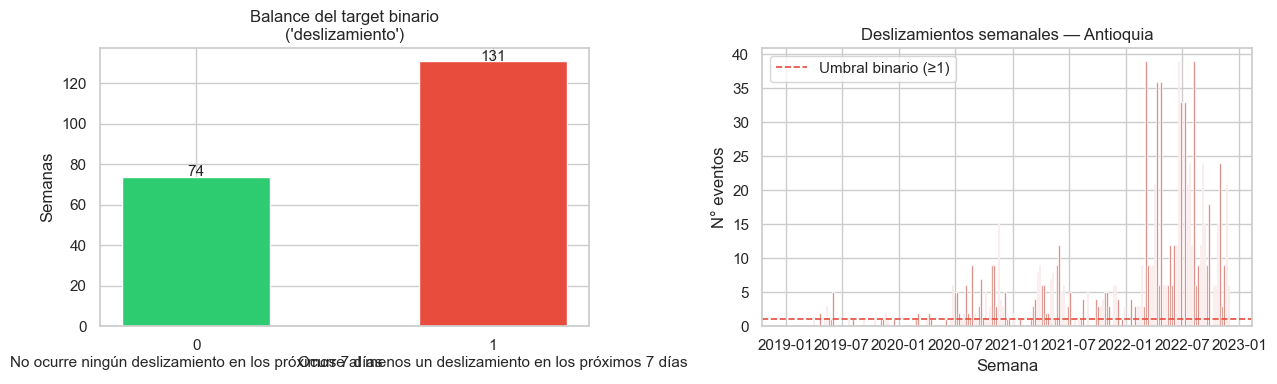

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Balance de clases
colores = {0: "#2ecc71", 1: "#e74c3c"}
vc      = df_semanal[cfg.target.nombre].value_counts().sort_index()
labels  = {0: cfg.target.clase_negativa_desc, 1: cfg.target.clase_positiva_desc}
axes[0].bar(
    [f"{k}\n{labels[k]}" for k in vc.index],
    vc.values,
    color=[colores[k] for k in vc.index],
    edgecolor="white",
    width=0.5,
)
axes[0].set_title(f"Balance del target binario\n('{cfg.target.nombre}')")
axes[0].set_ylabel("Semanas")
for i, val in enumerate(vc.values):
    axes[0].text(i, val + 0.2, str(val), ha="center", fontsize=11)

# Serie temporal semanal de deslizamientos
ts = df_semanal.copy()
ts["fecha_semana"] = ts["anio_semana"].dt.to_timestamp()
axes[1].bar(
    ts["fecha_semana"], ts["n_deslizamientos"],
    color="#c0392b", width=5, alpha=0.8, edgecolor="white"
)
axes[1].axhline(1, color="#e74c3c", linestyle="--", linewidth=1.2, label="Umbral binario (≥1)")
axes[1].set_title(f"Deslizamientos semanales — {cfg.geo.departamento.title()}")
axes[1].set_ylabel("N° eventos")
axes[1].set_xlabel("Semana")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Feature engineering

Las features ya fueron construidas por `aggregate_weekly_ideam()` en `process.py`.
Esta sección verifica que todas las features definidas en el config estén presentes
en el dataset y aplica el `dropna` sobre las features mínimas requeridas.

Las features de precipitación con ventana deslizante no necesitan un `shift`
adicional aquí porque `aggregate_weekly_ideam()` ya las construye tomando los
14 días **previos** al último día de cada semana — no hay riesgo de data leakage.

In [8]:
FEATURES = [f for f in cfg.all_features if f in df_semanal.columns]

# Verificar si falta alguna feature del config
features_faltantes = [f for f in cfg.all_features if f not in df_semanal.columns]
if features_faltantes:
    print(f"⚠ Features del config no encontradas en el dataset:")
    for f in features_faltantes:
        print(f"    - {f}")
    print("  Verificar aggregate_weekly_ideam() en process.py")
else:
    print(f"✓ Todas las features del config están presentes en el dataset")

# Eliminar semanas sin historial suficiente (primeras semanas del período)
df = df_semanal.dropna(subset=cfg.features.required_for_model).reset_index(drop=True)

print(f"\nDataset final : {len(df):,} semanas")
print(f"Features activas ({len(FEATURES)}): {FEATURES}")
display(df[FEATURES + ["n_deslizamientos", cfg.target.nombre]].describe().round(2))

✓ Todas las features del config están presentes en el dataset

Dataset final : 204 semanas
Features activas (10): ['precip_acum_14d', 'precip_max_diario_14d', 'precip_dias_lluvia_14d', 'precip_acum_7d', 'precip_acum_3d', 'n_estaciones', 'semana_sin', 'semana_cos', 'mes_sin', 'mes_cos']


,precip_acum_14d,precip_max_diario_14d,precip_dias_lluvia_14d,precip_acum_7d,precip_acum_3d,n_estaciones,semana_sin,semana_cos,mes_sin,mes_cos,n_deslizamientos,deslizamiento
count,204.00,204.00,204.00,204.00,204.00,204.00,204.0,204.0,204.00,204.00,204.00,204.00
mean,16.07,16.07,0.44,7.94,3.30,12.21,0.0,-0.02,-0.01,-0.02,4.60,0.64
std,31.80,31.80,0.50,23.83,16.01,23.05,0.72,0.7,0.71,0.70,7.78,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,-1.0,-1.0,-1.00,-1.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,-0.75,-0.75,-0.87,-0.87,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.0,-0.0,0.00,-0.00,1.00,1.00
75%,15.49,15.49,1.00,0.00,0.00,0.00,0.75,0.66,0.50,0.50,6.00,1.00
max,160.14,160.14,1.00,160.14,160.14,79.50,1.0,1.0,1.00,1.00,39.00,1.00


## 6. Calidad de datos — cobertura de sensores

Las semanas con baja cobertura de sensores son un proxy de **fallos en la red IDEAM**.
En esas semanas, el acumulado de precipitación puede estar subestimado porque
hay menos estaciones reportando, lo que introduce ruido en las features.

Se identifican usando el percentil definido en `calidad.cobertura_sensor_percentil`
del config para que el umbral sea reproducible y versionable.

In [9]:
umbral_cobertura = df["n_estaciones"].quantile(cfg.calidad.cobertura_sensor_percentil / 100)

print("=" * 50)
print("DIAGNÓSTICO DE DATOS FALTANTES")
print("=" * 50)

missings = df[FEATURES].isnull().sum()
diag     = missings[missings > 0].to_frame("n_missing")
diag["pct"] = (diag["n_missing"] / len(df) * 100).round(1)
if len(diag):
    display(diag)
else:
    print("✓ Sin datos faltantes en el período.")

semanas_baja = df[df["n_estaciones"] < umbral_cobertura]
print(
    f"\nSemanas con baja cobertura de sensores"
    f" (<p{cfg.calidad.cobertura_sensor_percentil} = {umbral_cobertura:.0f} registros):"
    f" {len(semanas_baja)}"
)
if len(semanas_baja):
    display(semanas_baja[["anio_semana", "n_estaciones",
                           "precip_acum_14d", cfg.target.nombre]])

DIAGNÓSTICO DE DATOS FALTANTES
✓ Sin datos faltantes en el período.

Semanas con baja cobertura de sensores (<p25 = 0 registros): 0


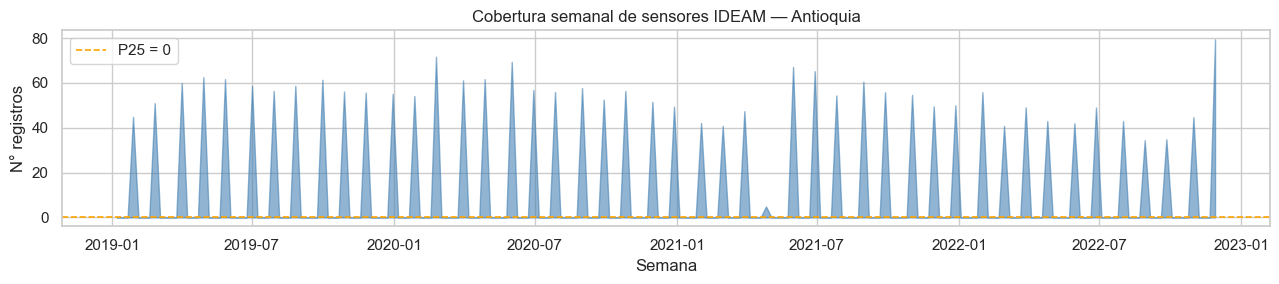

In [10]:
fig, ax = plt.subplots(figsize=(13, 3))
ts_idx = df["anio_semana"].dt.to_timestamp()
ax.fill_between(ts_idx, df["n_estaciones"], alpha=0.6, color="steelblue")
ax.axhline(
    umbral_cobertura, color="orange", linestyle="--", linewidth=1.2,
    label=f"P{cfg.calidad.cobertura_sensor_percentil} = {umbral_cobertura:.0f}"
)
ax.set_title(f"Cobertura semanal de sensores IDEAM — {cfg.geo.departamento.title()}")
ax.set_ylabel("N° registros")
ax.set_xlabel("Semana")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Persistencia y tracking MLflow

In [11]:
import shutil

cfg.processed_dir.mkdir(parents=True, exist_ok=True)
output_path    = cfg.processed_dir / f"{cfg.geo.departamento}_deslizamientos_semanal_v1.csv"
config_snapshot = cfg.processed_dir / "config_snapshot_v2.yaml"

df.to_csv(output_path, index=False)
shutil.copy(_root / "configs" / "antioquia_deslizamientos.yaml", config_snapshot)

print(f"✓ Dataset guardado  : {output_path.relative_to(_root)}")
print(f"✓ Config snapshot   : {config_snapshot.name}")

✓ Dataset guardado  : data\processed\antioquia_deslizamientos_semanal_v1.csv
✓ Config snapshot   : config_snapshot_v2.yaml


In [12]:
mlflow.set_tracking_uri(cfg.mlflow_tracking_uri)
mlflow.set_experiment(cfg.mlflow.experiment_name)

with mlflow.start_run(run_name="dataset_semanal_v1", tags=cfg.mlflow.run_tags) as run:
    mlflow.log_params(cfg.as_mlflow_params())

    n_pos = int(df[cfg.target.nombre].sum())
    n_neg = len(df) - n_pos

    mlflow.log_metrics({
        "n_semanas"                  : len(df),
        "n_deslizamientos_total"     : int(df["n_deslizamientos"].sum()),
        "n_semanas_con_evento"       : n_pos,
        "n_semanas_sin_evento"       : n_neg,
        "pct_clase_positiva"         : float(n_pos / len(df)),
        "ratio_desbalance"           : float(n_neg / n_pos) if n_pos > 0 else 0,
        "precip_acum14d_media"       : float(df["precip_acum_14d"].mean()),
        "precip_acum14d_max"         : float(df["precip_acum_14d"].max()),
        "n_features"                 : len(FEATURES),
        "semanas_baja_cobertura"     : len(semanas_baja),
    })

    mlflow.log_artifact(str(output_path))
    mlflow.log_artifact(str(config_snapshot))

    print(f"✓ MLflow run: {run.info.run_id}")
    print(f"  Experimento : {cfg.mlflow.experiment_name}")
    print(f"  Run name    : dataset_semanal_v1")

✓ MLflow run: fb62b6bcb75c4961bd8572708ddc9e3c
  Experimento : antioquia_deslizamientos_binario
  Run name    : dataset_semanal_v1


In [13]:
# Verificar cobertura diaria en Antioquia
df_ideam["fecha_dia"] = df_ideam["fecha"].dt.date
cobertura_diaria = df_ideam.groupby("fecha_dia")["precip_mm"].count()

dias_totales    = (df_ideam["fecha"].max() - df_ideam["fecha"].min()).days
dias_con_datos  = len(cobertura_diaria)
pct_cobertura   = dias_con_datos / dias_totales

print(f"Días totales en el período : {dias_totales}")
print(f"Días con al menos 1 lectura: {dias_con_datos} ({pct_cobertura:.1%})")
print(f"Días sin datos             : {dias_totales - dias_con_datos}")

# Si pct_cobertura < 0.70 el enfoque semanal tiene riesgo alto
# Si pct_cobertura >= 0.85 el enfoque es viable con la imputación actual

Días totales en el período : 1430
Días con al menos 1 lectura: 48 (3.4%)
Días sin datos             : 1382


## 8. Resumen y entregable para Notebook 02

El dataset resultante tiene la siguiente estructura lista para modelado:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `anio_semana` | Period (W) | Semana ISO del año |
| `precip_acum_14d` | float | Precipitación acumulada en los 14 días previos al cierre de la semana |
| `precip_acum_7d` | float | Precipitación acumulada en los últimos 7 días |
| `precip_acum_3d` | float | Precipitación acumulada en los últimos 3 días |
| `precip_max_diario_14d` | float | Máximo diario registrado en la ventana de 14 días |
| `precip_dias_lluvia_14d` | float | Días con lluvia > 0 mm en la ventana de 14 días |
| `semana_sin`, `semana_cos` | float | Encoding cíclico de la semana del año |
| `mes_sin`, `mes_cos` | float | Encoding cíclico del mes (bimodalidad lluvias Colombia) |
| `n_deslizamientos` | int | Conteo real de eventos la semana siguiente (análisis, no modelo) |
| `deslizamiento` | int (0/1) | **Target binario** — ocurrencia semana S+1 |

**Notebook 02** tomará este CSV y construirá la fase de experiment tracking
con `TimeSeriesSplit` para respetar el orden cronológico del problema.

In [14]:
print("=" * 60)
print("RESUMEN — DATASET SEMANAL v1")
print("=" * 60)
print(f"  Departamento        : {cfg.geo.departamento.title()}")
print(f"  Período             : {cfg.periodo.anio_inicio} – {cfg.periodo.anio_fin}")
print(f"  Granularidad        : semanal")
print(f"  Ventana precipit.   : {cfg.ventanas.precipitacion_dias} días")
print(f"  Horizonte predic.   : {cfg.ventanas.prediccion_dias} días")
print(f"  Semanas analizadas  : {len(df):,}")
print(f"  Target              : '{cfg.target.nombre}' (binario)")
n_pos = int(df[cfg.target.nombre].sum())
n_neg = len(df) - n_pos
print(f"  Clase 1 (evento)    : {n_pos} semanas ({n_pos/len(df):.1%})")
print(f"  Clase 0 (no evento) : {n_neg} semanas ({n_neg/len(df):.1%})")
if n_pos > 0:
    print(f"  Ratio desbalance    : 1:{n_neg/n_pos:.1f}")
print(f"  Features activas    : {len(FEATURES)}")
print(f"  Archivo output      : data/processed/{cfg.geo.departamento}_deslizamientos_semanal_v1.csv")
print(f"  MLflow tracking     : {cfg.mlflow.db_path}")
print("=" * 60)

RESUMEN — DATASET SEMANAL v1
  Departamento        : Antioquia
  Período             : 2019 – 2022
  Granularidad        : semanal
  Ventana precipit.   : 14 días
  Horizonte predic.   : 7 días
  Semanas analizadas  : 204
  Target              : 'deslizamiento' (binario)
  Clase 1 (evento)    : 131 semanas (64.2%)
  Clase 0 (no evento) : 73 semanas (35.8%)
  Ratio desbalance    : 1:0.6
  Features activas    : 10
  Archivo output      : data/processed/antioquia_deslizamientos_semanal_v1.csv
  MLflow tracking     : mlruns/mlflow.db
